# Notebook 1 — Data, PSD, and Whitening Infrastructure (v13)
### Detectability-Aware Post-Merger GW Anomaly Screening — Project Notebook 1/4

**Purpose of this notebook.** This is the foundation layer for the whole project. Everything downstream
(injection, time-frequency graph construction, detectability calibration, Stage-2 scoring) depends on the
objects built here being correct, so this notebook is deliberately conservative and heavy on sanity checks.



In [ ]:
# ---------------------------------------------------------------------------
# 0. Installs (Colab)
# ---------------------------------------------------------------------------
!pip install -q gwpy numpy scipy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.5/316.5 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.2/45.2 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.0/115.0 kB 4.9 MB/s eta 0:00:00


In [ ]:
# ---------------------------------------------------------------------------
# 1. Imports, seed, global config
# ---------------------------------------------------------------------------
import os
import json
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt
from gwpy.timeseries import TimeSeries

SEED = 42
np.random.seed(SEED)

# Output directory for cached data / derived artifacts. In Colab, point this at a
# mounted Google Drive folder if you want caches to survive session restarts:
from google.colab import drive; drive.mount('/content/drive')
OUT_DIR = '/content/drive/MyDrive/gw_postmerger/nb1_artifacts'
#OUT_DIR = './nb1_artifacts'
os.makedirs(OUT_DIR, exist_ok=True)

DETECTOR = 'L1'
FS = 16384  # native LIGO sample rate in Hz -- used consistently everywhere, no relabeling later
WINDOW_DUR = 0.1  # seconds, matches the post-merger analysis window used in later notebooks
N_SAMPLES_WINDOW = int(FS * WINDOW_DUR)

print(f"Detector: {DETECTOR}, fs = {FS} Hz, window = {WINDOW_DUR*1000:.0f} ms "
      f"({N_SAMPLES_WINDOW} samples/window)")

Mounted at /content/drive
Detector: L1, fs = 16384 Hz, window = 100 ms (1638 samples/window)


## 2. Locate valid GPS blocks via GWOSC's data-quality timeline

**Why this changed from v2:** v2 fetched a candidate GPS window and *then* checked whether it happened
to be full of `NaN`, expanding the search if not. Running it hit a window with a **100% gap fraction that
persisted even after expanding to a 3.4-hour search span** -- that's not a short lock-loss glitch, it's an
entire multi-hour non-observing stretch (LIGO duty cycles are typically 60-70%, so hours-long outages are
routine, and the anchor epoch happened to land in one). Blind fetch-then-scan is also wasteful: it
downloads full 16 kHz strain just to discover it's unusable.

**v3 approach:** query GWOSC's public data-quality timeline (the `gwosc` package's `L1_DATA` flag) for the
GPS ranges where the detector was actually taking data, *before* downloading any strain at all. This is a
lightweight metadata query, not a data download. We then pack our four blocks sequentially into the
returned good-data segments (each block placed entirely inside one segment, so it can never straddle a
gap), and only fetch the exact final GPS ranges we've already verified are good. Finiteness is still
asserted on the fetched strain as a safety net, but it should now always pass by construction.


In [ ]:
# ---------------------------------------------------------------------------
# 2. Locate valid GPS blocks using GWOSC's data-quality timeline
# ---------------------------------------------------------------------------
!pip install -q gwosc
from gwosc.timeline import get_segments

GW170817_GPS = 1187008882.4
GUARD_S = 8.0                      # seconds of buffer between blocks
DATA_FLAG = f'{DETECTOR}_DATA'     # "detector was taking data" segments
SEARCH_WINDOW_S = 5 * 86400.0      # look back up to 5 days for enough good time
SEARCH_END = GW170817_GPS - 3600.0     # stay >= 1 hour clear of the event itself
SEARCH_START = SEARCH_END - SEARCH_WINDOW_S

BLOCK_SPECS = [("psd_block", 2048.0), ("calib_block", 1024.0),
               ("train_block", 1024.0), ("test_block", 1024.0)]

def allocate_blocks(segments, block_specs, guard=GUARD_S):
    """Greedily pack each block into the first segment with enough remaining room, in chronological
    order. Every block lies fully within a single good-data segment -- it can never straddle a gap."""
    segments = sorted(segments, key=lambda se: se[0])
    remaining = list(block_specs)
    allocation = {}
    for (seg_start, seg_end) in segments:
        cursor = seg_start
        while remaining and cursor + remaining[0][1] <= seg_end:
            name, dur = remaining.pop(0)
            allocation[name] = (cursor, cursor + dur)
            cursor += dur + guard
        if not remaining:
            break
    if remaining:
        raise RuntimeError(
            f"Could not place blocks {[n for n, _ in remaining]} within the available segments -- "
            f"widen SEARCH_WINDOW_S (currently {SEARCH_WINDOW_S/86400:.1f} days) or move SEARCH_END."
        )
    return allocation

manifest_path = os.path.join(OUT_DIR, "gps_blocks.json")
cached_raw_paths = {n: os.path.join(OUT_DIR, f"raw_{n}_{DETECTOR}.npy") for n, _ in BLOCK_SPECS}

if os.path.exists(manifest_path) and all(os.path.exists(p) for p in cached_raw_paths.values()):
    print("Found cached block layout + raw data -- loading from disk instead of re-querying GWOSC.")
    BLOCKS = json.load(open(manifest_path))
    raw_strain = {n: np.load(p) for n, p in cached_raw_paths.items()}
    for n, arr in raw_strain.items():
        assert np.all(np.isfinite(arr)), f"[{n}] cached raw strain unexpectedly non-finite!"
else:
    print(f"Querying {DATA_FLAG} segments over GPS [{SEARCH_START:.0f}, {SEARCH_END:.0f}) "
          f"({SEARCH_WINDOW_S/86400:.1f} days)...")
    raw_segments = get_segments(DATA_FLAG, int(SEARCH_START), int(SEARCH_END))
    segments = sorted([(float(s), float(e)) for s, e in raw_segments if (e - s) >= 60.0],
                       key=lambda se: se[0])
    total_good_s = sum(e - s for s, e in segments)
    total_needed = sum(d for _, d in BLOCK_SPECS) + GUARD_S * (len(BLOCK_SPECS) - 1)
    print(f"Found {len(segments)} usable segments, {total_good_s:.0f}s of good-data time "
          f"({total_good_s/SEARCH_WINDOW_S:.1%} duty cycle in this window); need >= {total_needed:.0f}s.")
    assert total_good_s >= total_needed, (
        "Not enough good-data time found in the search window -- widen SEARCH_WINDOW_S above."
    )

    allocation = allocate_blocks(segments, BLOCK_SPECS)

    BLOCKS = {}
    raw_strain = {}
    print()
    for name, (start, end) in allocation.items():
        dur = end - start
        print(f"[{name}] fetching verified-good GPS [{start:.1f}, {end:.1f}) ({dur:.0f}s)...")
        # IMPORTANT: fetch_open_data defaults to sample_rate=4096 Hz. Our post-merger band of
        # interest (1.5-4 kHz) sits at/above that Nyquist, so we must explicitly request 16384 Hz
        # and refuse to silently upsample if it isn't available -- upsampling a 4096 Hz file cannot
        # manufacture real content above its true 2048 Hz Nyquist and would silently corrupt exactly
        # the frequency band this whole project depends on.
        ts = TimeSeries.fetch_open_data(DETECTOR, start, end, sample_rate=FS, cache=True, verbose=False)
        actual_fs = int(round(ts.sample_rate.value))
        assert actual_fs == FS, (
            f"[{name}] requested {FS} Hz data but GWOSC returned {actual_fs} Hz. Refusing to "
            f"upsample (that would fabricate content above the true Nyquist and silently corrupt "
            f"the analysis band -- this is exactly the v3 bug). 16 kHz data may not be available "
            f"for this GPS range; try a different epoch."
        )
        arr = ts.value.astype(np.float64)
        assert np.all(np.isfinite(arr)), (
            f"[{name}] segment was reported as good by {DATA_FLAG} but strain still contains "
            f"non-finite values -- the DATA flag marks presence of data, not full validation. Try a "
            f"different segment, or additionally filter by a quality flag such as "
            f"'{DETECTOR}_CBC_CAT1'."
        )
        raw_strain[name] = arr
        BLOCKS[name] = {"name": name, "start": start, "end": end, "duration": dur}
        np.save(cached_raw_paths[name], arr)

    with open(manifest_path, "w") as f:
        json.dump(BLOCKS, f, indent=2)
    print(f"\nSaved block layout -> {manifest_path}")

def assert_non_overlapping(blocks):
    spans = sorted(blocks.values(), key=lambda b: b["start"])
    for a, b in zip(spans[:-1], spans[1:]):
        assert a["end"] <= b["start"], f"Overlap detected between {a['name']} and {b['name']}!"
    print("OK: all GPS blocks are non-overlapping.")

assert_non_overlapping(BLOCKS)
print()
for name, b in BLOCKS.items():
    print(f"{name:12s}  GPS [{b['start']:.1f}, {b['end']:.1f})  duration={b['duration']:.0f}s")
    assert np.all(np.isfinite(raw_strain[name])), f"{name}: raw strain unexpectedly non-finite!"


Querying L1_DATA segments over GPS [1186573282, 1187005282) (5.0 days)...
Found 19 usable segments, 332559s of good-data time (77.0% duty cycle in this window); need >= 5144s.

[psd_block] fetching verified-good GPS [1186573282.0, 1186575330.0) (2048s)...
[calib_block] fetching verified-good GPS [1186575338.0, 1186576362.0) (1024s)...
[train_block] fetching verified-good GPS [1186576370.0, 1186577394.0) (1024s)...
[test_block] fetching verified-good GPS [1186577402.0, 1186578426.0) (1024s)...

Saved block layout -> /content/drive/MyDrive/gw_postmerger/nb1_artifacts/gps_blocks.json
OK: all GPS blocks are non-overlapping.

psd_block     GPS [1186573282.0, 1186575330.0)  duration=2048s
calib_block   GPS [1186575338.0, 1186576362.0)  duration=1024s
train_block   GPS [1186576370.0, 1186577394.0)  duration=1024s
test_block    GPS [1186577402.0, 1186578426.0)  duration=1024s


## 3. PSD estimation (Welch / median-of-segments, from `psd_block` only)

Estimated **from real off-source data**, using `gwpy`'s median-averaged Welch estimator (the same family
of estimator LIGO pipelines use), from a block that is never itself used as an analysis window. Every
whitening operation in every other block uses this single fixed PSD estimate.

`estimate_psd` now asserts the result is fully finite before returning it, so a data problem is caught
here, at the source, rather than silently producing an invisible plot two cells later.


In [ ]:
# ---------------------------------------------------------------------------
# 3. PSD estimation: median baseline + percentile-based intermittency detection
# ---------------------------------------------------------------------------
# v12 switched the WHOLE PSD estimate from median to 99th-percentile-across-segments to catch
# intermittent lines. It worked partially (SNR-recovery std dropped from ~10 to ~4.5) but
# over-corrected: for stationary Gaussian noise, a single-segment periodogram is exponentially
# distributed, and its 99th percentile is a FIXED ~6.6x its median regardless of any real line --
# so switching the entire estimate to percentile inflated the whole continuum uniformly (whitened
# flatness sat at ~0.2 everywhere, not just at lines), not just the genuinely intermittent bins.
#
# v13 is surgical: use the median (bias-corrected, proven accurate away from lines -- this is what
# gave flatness~1.0 in non-line regions back in v9-v11) as the baseline EVERYWHERE, and use a
# SEPARATE 99th-percentile estimate only to DETECT bins that are intermittent beyond what normal
# stationary statistical fluctuation would produce (i.e. where percentile/median exceeds the typical
# ratio by a further factor), then inflate ONLY those flagged bins using the percentile value.
# Bins that aren't flagged keep their accurate median value -- no more broadband over-conservatism.
PSD_FFTLENGTH = 4.0    # seconds per Welch segment
PSD_OVERLAP = 2.0      # seconds overlap (50%)
PSD_PERCENTILE = 99.0  # used only for intermittency DETECTION and as the inflation source, not as the baseline
LINE_BASELINE_KERNEL_HZ = 100.0  # local median-filter window for the smooth continuum baseline
PERSISTENT_LINE_FACTOR = 5.0     # bin counts as a 'persistent line' if it exceeds this x the local median baseline
INTERMITTENCY_FACTOR = 2.5       # bin counts as 'intermittent' if percentile/median exceeds this x the TYPICAL such ratio
LINE_EXTRA_MARGIN = 5.0          # flagged bins get max(percentile, median) x this margin
ENVELOPE_BLOCKS = ['psd_block', 'calib_block', 'train_block']  # test_block deliberately excluded

def estimate_psd_dual(raw_array, fs=FS, fftlength=PSD_FFTLENGTH, overlap=PSD_OVERLAP, percentile=PSD_PERCENTILE):
    """Returns (freqs, median_vals, percentile_vals). median_vals uses gwpy's bias-corrected median
    estimator (accurate baseline); percentile_vals uses raw per-segment periodograms aggregated with
    np.percentile (used only for intermittency detection/inflation, not as a baseline)."""
    assert np.all(np.isfinite(raw_array)), "estimate_psd_dual: input contains non-finite values."
    ts = TimeSeries(raw_array, sample_rate=fs)
    psd_median = ts.psd(fftlength=fftlength, overlap=overlap, method='median')
    freqs_m, median_vals = psd_median.frequencies.value, psd_median.value

    nperseg = int(round(fftlength * fs))
    noverlap = int(round(overlap * fs))
    freqs_p, _times, Sxx = signal.spectrogram(raw_array, fs=fs, window='hann', nperseg=nperseg,
                                               noverlap=noverlap, scaling='density', mode='psd',
                                               detrend='constant')
    percentile_vals = np.percentile(Sxx, percentile, axis=1)
    assert np.allclose(freqs_m, freqs_p), "median/percentile frequency grids don't match -- check nperseg/noverlap consistency."
    assert np.all(np.isfinite(median_vals)) and np.all(np.isfinite(percentile_vals))
    return freqs_m, median_vals, percentile_vals

def build_safe_psd(freqs, median_env, percentile_env, baseline_kernel_hz=LINE_BASELINE_KERNEL_HZ,
                    persistent_factor=PERSISTENT_LINE_FACTOR, intermittency_factor=INTERMITTENCY_FACTOR,
                    extra_margin=LINE_EXTRA_MARGIN):
    df = freqs[1] - freqs[0]
    kernel_bins = max(3, int(round(baseline_kernel_hz / df)))
    if kernel_bins % 2 == 0:
        kernel_bins += 1
    smoothed_baseline = signal.medfilt(median_env, kernel_size=kernel_bins)
    persistent_mask = median_env > persistent_factor * smoothed_baseline

    ratio = percentile_env / median_env
    typical_ratio = float(np.median(ratio))  # the 'normal' percentile/median ratio for stationary noise
    intermittent_mask = ratio > intermittency_factor * typical_ratio

    line_mask = persistent_mask | intermittent_mask
    safe_values = median_env.copy()
    safe_values[line_mask] = np.maximum(percentile_env[line_mask], median_env[line_mask]) * extra_margin
    return safe_values, line_mask, persistent_mask, intermittent_mask, smoothed_baseline, typical_ratio

_per_block_median = {}
_per_block_percentile = {}
psd_freqs = None
for _name in ENVELOPE_BLOCKS:
    _freqs, _med, _pct = estimate_psd_dual(raw_strain[_name])
    _per_block_median[_name] = _med
    _per_block_percentile[_name] = _pct
    if psd_freqs is None:
        psd_freqs = _freqs
    assert np.allclose(_freqs, psd_freqs), f"{_name}: frequency grid mismatch -- fftlength/fs inconsistency?"

psd_median_envelope = np.maximum.reduce([_per_block_median[n] for n in ENVELOPE_BLOCKS])
psd_percentile_envelope = np.maximum.reduce([_per_block_percentile[n] for n in ENVELOPE_BLOCKS])
_argmax_block = np.argmax(np.stack([_per_block_median[n] for n in ENVELOPE_BLOCKS], axis=0), axis=0)

psd_values, line_mask, persistent_mask, intermittent_mask, psd_baseline, typical_ratio = build_safe_psd(
    psd_freqs, psd_median_envelope, psd_percentile_envelope)
psd_values_raw = psd_median_envelope  # kept under this name for the Section 4 diagnostic plot below

n_segments = int((BLOCKS['psd_block']['duration'] - PSD_OVERLAP) / (PSD_FFTLENGTH - PSD_OVERLAP))
n_persistent = int(persistent_mask.sum())
n_intermittent = int((intermittent_mask & ~persistent_mask).sum())
n_lines = int(line_mask.sum())
print(f"Estimated PSD (median baseline + percentile intermittency detection) independently from "
      f"{ENVELOPE_BLOCKS} ({PSD_FFTLENGTH}s segments), then took the element-wise max as an envelope "
      f"(test_block excluded).")
print(f"Frequency resolution: {psd_freqs[1]-psd_freqs[0]:.4f} Hz, "
      f"range: [{psd_freqs[0]:.1f}, {psd_freqs[-1]:.1f}] Hz")
for _i, _name in enumerate(ENVELOPE_BLOCKS):
    _frac = float(np.mean(_argmax_block == _i))
    print(f"  {_name:12s}: contributed the median-envelope max at {_frac:.1%} of frequency bins")
print(f"Typical (stationary-noise) percentile/median ratio: {typical_ratio:.2f}")
print(f"Flagged {n_persistent} persistent-line bin(s) and {n_intermittent} additional intermittent-only "
      f"bin(s) ({n_lines} total) -- each set to max(percentile, median) x {LINE_EXTRA_MARGIN}.")
print(f"All finite: {np.all(np.isfinite(psd_values))}, "
      f"value range: [{psd_values.min():.3e}, {psd_values.max():.3e}]")

np.savez(os.path.join(OUT_DIR, "estimated_psd.npz"),
         freqs=psd_freqs, psd=psd_values, psd_raw=psd_values_raw, line_mask=line_mask)
print(f"Saved -> {os.path.join(OUT_DIR, 'estimated_psd.npz')} "
      f"(keys: freqs, psd [median baseline + flagged-line inflation, USE THIS], psd_raw [median "
      f"envelope only, diagnostic], line_mask)")


Estimated PSD (median baseline + percentile intermittency detection) independently from ['psd_block', 'calib_block', 'train_block'] (4.0s segments), then took the element-wise max as an envelope (test_block excluded).
Frequency resolution: 0.2500 Hz, range: [0.0, 8192.0] Hz
  psd_block   : contributed the median-envelope max at 31.1% of frequency bins
  calib_block : contributed the median-envelope max at 34.0% of frequency bins
  train_block : contributed the median-envelope max at 35.0% of frequency bins
Typical (stationary-noise) percentile/median ratio: 4.61
Flagged 455 persistent-line bin(s) and 0 additional intermittent-only bin(s) (455 total) -- each set to max(percentile, median) x 5.0.
All finite: True, value range: [9.211e-59, 1.230e-37]
Saved -> /content/drive/MyDrive/gw_postmerger/nb1_artifacts/estimated_psd.npz (keys: freqs, psd [median baseline + flagged-line inflation, USE THIS], psd_raw [median envelope only, diagnostic], line_mask)


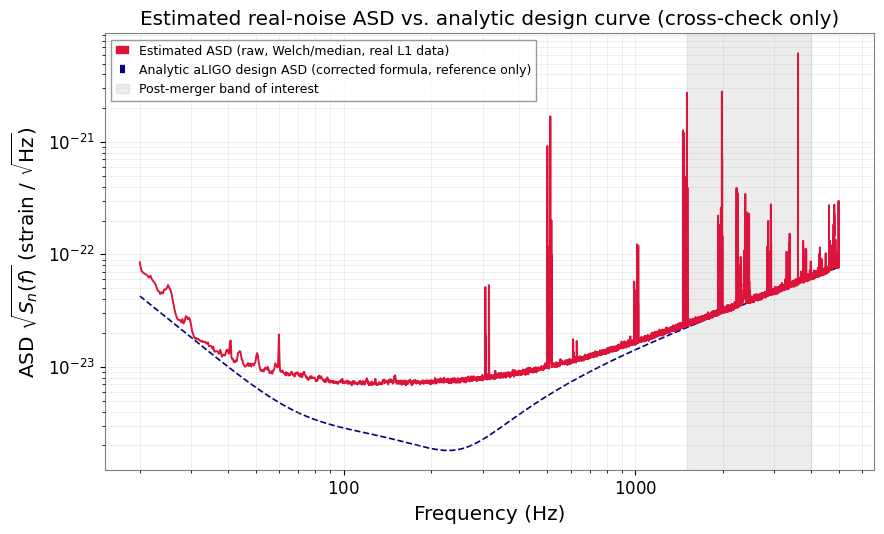

Real detector data is expected to sit above the design curve in places (spectral lines,
non-stationary artifacts) -- that's normal, and exactly why we whiten with the estimated
curve, not the analytic one.


In [ ]:
# ---------------------------------------------------------------------------
# Analytic aLIGO curve -- VISUAL CROSS-CHECK ONLY. Never used for whitening.
# Corrected form (cf. e.g. arXiv:gr-qc/0503124, arXiv:1004.0284): the previous
# version of this project used a corrupted variant of this formula; this is the
# standard fit.
# ---------------------------------------------------------------------------
def analytic_aligo_psd(freqs, S0=1e-49, f0=215.0, f_low=10.0):
    freqs = np.asarray(freqs, dtype=float)
    psd = np.full_like(freqs, np.inf)
    valid = freqs > f_low
    x = freqs[valid] / f0
    psd[valid] = S0 * (x**-4.14 - 5.0 * x**-2 + 111.0 * (1 - x**2 + x**4/2) / (1 + x**2/2))
    return psd

analytic_freqs = psd_freqs.copy()
analytic_psd = analytic_aligo_psd(analytic_freqs)

fig, ax = plt.subplots(figsize=(9, 5.5))
band = (psd_freqs >= 20) & (psd_freqs <= 5000)
assert band.sum() > 0 and np.all(np.isfinite(psd_values_raw[band])), \
    "Nothing finite to plot in the [20, 5000] Hz band -- check psd_values_raw above before plotting."

ax.loglog(psd_freqs[band], np.sqrt(psd_values_raw[band]), label='Estimated ASD (raw, Welch/median, real L1 data)',
          color='crimson', lw=1.4, zorder=3)
finite = np.isfinite(analytic_psd) & band
ax.loglog(analytic_freqs[finite], np.sqrt(analytic_psd[finite]),
          label='Analytic aLIGO design ASD (corrected formula, reference only)',
          color='navy', ls='--', lw=1.2, zorder=2)
ax.axvspan(1500, 4000, color='gray', alpha=0.15, label='Post-merger band of interest')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel(r'ASD $\sqrt{S_n(f)}$ (strain / $\sqrt{\mathrm{Hz}}$)')
ax.set_title('Estimated real-noise ASD vs. analytic design curve (cross-check only)')
ax.legend(fontsize=9)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'plot_asd_comparison.pdf'))
plt.show()

print("Real detector data is expected to sit above the design curve in places (spectral lines,")
print("non-stationary artifacts) -- that's normal, and exactly why we whiten with the estimated")
print("curve, not the analytic one.")


## 4. Whitening

Whitening divides the Fourier transform of a window by the *estimated* ASD (interpolated onto that
window's own frequency bins), not by the analytic curve. The estimated ASD comes only from `psd_block`,
so no window ever whitens itself with information drawn from itself. `whiten()` now asserts its own
output is finite, so a bad ASD bin is caught at the point of whitening, not several cells later.


In [ ]:
# ---------------------------------------------------------------------------
# 4. Whitening using the fixed, pre-estimated PSD
# ---------------------------------------------------------------------------
from scipy.interpolate import interp1d

assert np.all(np.isfinite(psd_values)) and np.all(psd_values > 0), \
    "psd_values must be finite and strictly positive before building the whitening interpolator."

# v5 assumed the only pathological (near-zero, Welch/median-estimator-artifact) PSD bin was at DC.
# That assumption was wrong: DC and the sub-20Hz band turned out to be physically normal (large, as
# expected from the seismic wall). The actual pathological bin(s) are somewhere at f >= 20 Hz, and
# since the "raw PSD" plot in Section 6b (plotted only over [20, 5000] Hz) never showed anything near
# 1e-59, they must sit above 5000 Hz -- almost certainly near the Nyquist edge (8192 Hz), where
# anti-aliasing roll-off and Welch/median edge effects are unreliable, mirroring the DC issue at the
# opposite end of the spectrum. Rather than assume, we diagnose this explicitly below and band-limit
# whitening to [F_LOW, F_HIGH], well clear of both ends -- which is also simply good practice: our
# post-merger band of interest is 1.5-4 kHz, and no real search whitens or trusts PSD estimates right
# at the seismic wall or right at Nyquist anyway.
F_LOW = 20.0     # Hz -- below this: seismic wall, not physically relevant here
F_HIGH = 6000.0  # Hz -- comfortably above our 1.5-4 kHz analysis band, comfortably below Nyquist (8192 Hz)
PATHOLOGY_THRESHOLD = 1e-50  # PSD values below this are treated as estimator artifacts, not real noise

_psd_interp = interp1d(psd_freqs, psd_values, bounds_error=False,
                        fill_value=(psd_values[0], psd_values[-1]))

# --- Diagnose: where are the pathologically small PSD values, anywhere in the full spectrum? ---
bad_mask = psd_values < PATHOLOGY_THRESHOLD
n_bad = bad_mask.sum()
if n_bad > 0:
    bad_freqs = psd_freqs[bad_mask]
    print(f"Found {n_bad} PSD bin(s) below {PATHOLOGY_THRESHOLD:.0e} (estimator artifacts, not real "
          f"noise): frequency range [{bad_freqs.min():.1f}, {bad_freqs.max():.1f}] Hz")
    in_band = bad_freqs[(bad_freqs >= F_LOW) & (bad_freqs <= F_HIGH)]
    if len(in_band) > 0:
        raise RuntimeError(
            f"{len(in_band)} pathological PSD bin(s) fall INSIDE the [{F_LOW}, {F_HIGH}] Hz analysis "
            f"band whiten() actually uses (at {sorted(in_band)[:10]}{'...' if len(in_band) > 10 else ''} "
            f"Hz) -- band-limiting alone won't fix this; the PSD estimate itself needs investigating "
            f"(e.g. a longer psd_block, a different fftlength, or excluding a specific known bad "
            f"frequency)."
        )
    else:
        print(f"All pathological bins fall OUTSIDE [{F_LOW}, {F_HIGH}] Hz -- band-limiting whiten() "
              f"to that range avoids them.")
else:
    print(f"No PSD bins below {PATHOLOGY_THRESHOLD:.0e} anywhere in the spectrum.")

_band_vals = psd_values[(psd_freqs >= F_LOW) & (psd_freqs <= F_HIGH)]
print(f"PSD value range within the [{F_LOW}, {F_HIGH}] Hz band whiten() uses: "
      f"[{_band_vals.min():.3e}, {_band_vals.max():.3e}]")
assert _band_vals.min() > PATHOLOGY_THRESHOLD, (
    f"PSD values are still pathologically small inside [{F_LOW}, {F_HIGH}] Hz after the diagnostic "
    f"above -- this should not happen; investigate the printed frequency range."
)

def whiten(data, fs=FS, psd_interp=_psd_interp, f_low=F_LOW, f_high=F_HIGH):
    """Whiten a real 1D array using the globally estimated PSD (interpolated to this array's bins),
    hard-zeroing content outside [f_low, f_high] instead of dividing by unreliable PSD estimates near
    DC or near Nyquist (see diagnostic above). Does NOT re-normalize by np.std afterward -- amplitude
    information is preserved here; any per-sample normalization is applied explicitly downstream
    (Notebook 2+) if/when needed, and should be treated as a deliberate, documented choice rather than
    a default.
    """
    assert np.all(np.isfinite(data)), "whiten(): input data contains non-finite values."
    n = len(data)
    freqs = np.fft.rfftfreq(n, d=1.0/fs)
    passband = (freqs >= f_low) & (freqs <= f_high)

    asd = np.sqrt(psd_interp(freqs[passband]))
    assert np.all(np.isfinite(asd)) and np.all(asd > 0), \
        "whiten(): interpolated ASD contains non-finite or non-positive values in the passband -- " \
        "check psd_freqs coverage vs. this window's Nyquist range."

    data_fft = np.fft.rfft(data)
    whitened_fft = np.zeros_like(data_fft)
    whitened_fft[passband] = data_fft[passband] / asd
    # bins outside [f_low, f_high] are left at 0 -- a deliberate band-limit, not an oversight.

    out = np.fft.irfft(whitened_fft, n=n)
    assert np.all(np.isfinite(out)), "whiten(): output contains non-finite values -- see asserts above."
    return out


Found 86 PSD bin(s) below 1e-50 (estimator artifacts, not real noise): frequency range [8167.2, 8192.0] Hz
All pathological bins fall OUTSIDE [20.0, 6000.0] Hz -- band-limiting whiten() to that range avoids them.
PSD value range within the [20.0, 6000.0] Hz band whiten() uses: [4.685e-47, 2.611e-40]


## 5. Windowing each block

Each block is cut into fixed-length, strictly non-overlapping `WINDOW_DUR`-second windows (no stride
overlap within a block, on top of the GPS-level guard gaps between blocks). We whiten every window using
the fixed PSD from Step 3.


In [ ]:
# ---------------------------------------------------------------------------
# 5. Whiten each block ONCE as a whole, trim edge artifacts, then slice into windows
# ---------------------------------------------------------------------------
# IMPORTANT: whitening a short (100ms) window on its own is, mathematically, a *circular*
# convolution over a tiny array -- the whitening filter's edge transients (normally confined to a
# couple of seconds at the true edges of a long stretch, per gwpy's own documented pattern
# `hp.whiten(4, 2).crop(start + 2, end - 2)`) instead land on top of every single short window, at
# both ends, every time. That's exactly the large spikes seen at t=0 and t=100ms previously. The fix
# is the same one real GW pipelines use: whiten a long, continuous stretch ONCE, then discard a few
# seconds at each end before slicing it into short analysis windows -- interior windows, far from the
# block's true edges, are then unaffected.
EDGE_TRIM_S = 4.0  # seconds discarded from each end of a whitened block before windowing

def make_windows(raw_array, n_samples=N_SAMPLES_WINDOW):
    """Non-overlapping windows, dropping any incomplete tail."""
    n_windows = len(raw_array) // n_samples
    trimmed = raw_array[: n_windows * n_samples]
    return trimmed.reshape(n_windows, n_samples)

whitened_windows = {}
whitened_blocks = {}  # kept around for the Section 6b/7 example plots below
edge_trim_samples = int(round(EDGE_TRIM_S * FS))
for name in ['calib_block', 'train_block', 'test_block']:
    block = raw_strain[name]
    whitened_full = whiten(block - block.mean())          # ONE whitening call over the whole block
    interior = whitened_full[edge_trim_samples: -edge_trim_samples]  # discard edge-transient region
    wn = make_windows(interior)
    assert np.all(np.isfinite(wn)), f"{name}: whitened window pool contains non-finite values!"
    whitened_windows[name] = wn
    whitened_blocks[name] = whitened_full
    print(f"{name:12s}: whitened as one {len(block)/FS:.0f}s block, trimmed {EDGE_TRIM_S:.0f}s off "
          f"each end, sliced into {wn.shape[0]} non-overlapping {WINDOW_DUR*1000:.0f}ms windows, "
          f"all finite")

for name, wn in whitened_windows.items():
    np.save(os.path.join(OUT_DIR, f"whitened_{name}.npy"), wn)
print(f"\nSaved whitened window pools to {OUT_DIR}/whitened_<block>.npy")


calib_block : whitened as one 1024s block, trimmed 4s off each end, sliced into 10162 non-overlapping 100ms windows, all finite
train_block : whitened as one 1024s block, trimmed 4s off each end, sliced into 10162 non-overlapping 100ms windows, all finite
test_block  : whitened as one 1024s block, trimmed 4s off each end, sliced into 10162 non-overlapping 100ms windows, all finite

Saved whitened window pools to /content/drive/MyDrive/gw_postmerger/nb1_artifacts/whitened_<block>.npy


## 6. Sanity checks

These are the checks that should have caught the v1 bug earlier than it was caught. All should pass on
real detector data whitened with its own estimated PSD:

1. **Finiteness** — already asserted at every stage above; re-confirmed here explicitly.
2. **Unit-ish variance** — whitened pure noise should have variance close to 1.
3. **Flat spectrum** — the power spectrum of whitened noise should be much flatter than the raw ASD was.
4. **Approximately Gaussian marginals** — real detector noise is not perfectly Gaussian, and that's
   expected (part of why later notebooks calibrate thresholds empirically rather than assuming
   Gaussianity), but it shouldn't be pathologically non-Gaussian.
5. **No block leakage** — explicit re-assertion that no window's timestamp range overlaps another block.


In [ ]:
# ---------------------------------------------------------------------------
# 6a. Finiteness + variance check
# ---------------------------------------------------------------------------
# Expected variance: by Parseval, a whitened signal with flat one-sided PSD ~= 1 over a passband of
# width (F_HIGH - F_LOW) has Var ~= integral of S(f) df ~= F_HIGH - F_LOW -- NOT O(1). (An earlier
# version of this comment incorrectly expected O(1); that was never right once whitening became
# band-limited to [F_LOW, F_HIGH] rather than the full Nyquist range.)
expected_variance = F_HIGH - F_LOW
for name, wn in whitened_windows.items():
    assert np.all(np.isfinite(wn)), f"{name}: non-finite values found in sanity check!"
    variances = wn.var(axis=1)
    print(f"{name:12s}: finite=True  variance mean={variances.mean():.1f}  std={variances.std():.1f}  "
          f"(expect ~{expected_variance:.0f}, i.e. ~F_HIGH-F_LOW, per Parseval for a flat-PSD~1 signal "
          f"band-limited to [{F_LOW:.0f},{F_HIGH:.0f}]Hz; somewhat below that is normal given the "
          f"deliberately suppressed line regions)")


calib_block : finite=True  variance mean=5600.0  std=233.1  (expect ~5980, i.e. ~F_HIGH-F_LOW, per Parseval for a flat-PSD~1 signal band-limited to [20,6000]Hz; somewhat below that is normal given the deliberately suppressed line regions)
train_block : finite=True  variance mean=5613.7  std=714.5  (expect ~5980, i.e. ~F_HIGH-F_LOW, per Parseval for a flat-PSD~1 signal band-limited to [20,6000]Hz; somewhat below that is normal given the deliberately suppressed line regions)
test_block  : finite=True  variance mean=5613.6  std=245.5  (expect ~5980, i.e. ~F_HIGH-F_LOW, per Parseval for a flat-PSD~1 signal band-limited to [20,6000]Hz; somewhat below that is normal given the deliberately suppressed line regions)


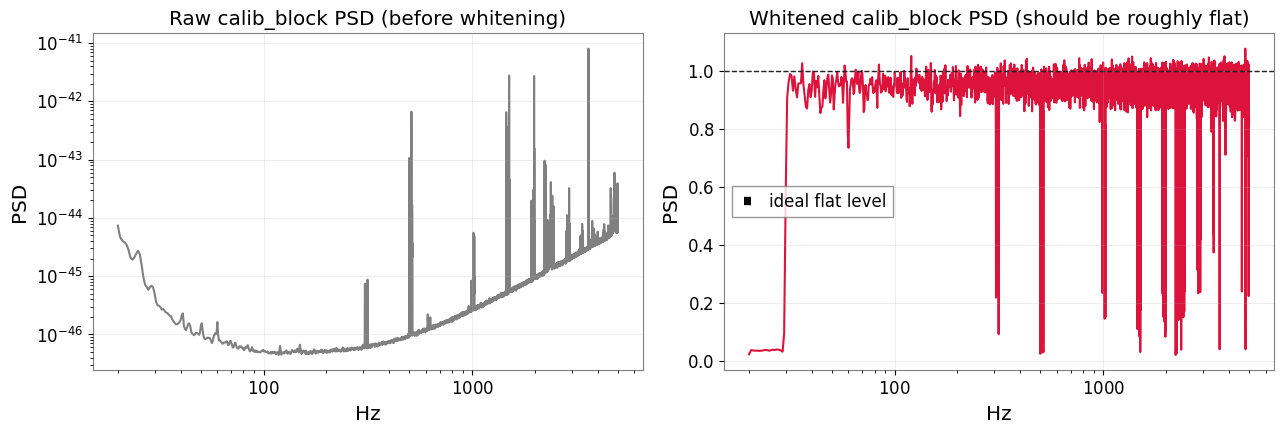

In [ ]:
# ---------------------------------------------------------------------------
# 6b. Flatness check -- compare raw vs whitened spectra on a longer stretch from calib_block
# ---------------------------------------------------------------------------
raw_calib = raw_strain['calib_block']
whitened_calib_long = whitened_blocks['calib_block']  # reuse the Section 5 whole-block whitening
assert np.all(np.isfinite(whitened_calib_long))

f_raw, p_raw = signal.welch(raw_calib, fs=FS, nperseg=FS*2)
f_wh, p_wh = signal.welch(whitened_calib_long, fs=FS, nperseg=FS*2)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
band_r = (f_raw >= 20) & (f_raw <= 5000)
axes[0].loglog(f_raw[band_r], p_raw[band_r], color='gray')
axes[0].set_title('Raw calib_block PSD (before whitening)')
axes[0].set_xlabel('Hz'); axes[0].set_ylabel('PSD'); axes[0].grid(True, alpha=0.3)

band_w = (f_wh >= 20) & (f_wh <= 5000)
axes[1].semilogx(f_wh[band_w], p_wh[band_w], color='crimson')
axes[1].axhline(1.0, color='k', ls='--', lw=1, label='ideal flat level')
axes[1].set_title('Whitened calib_block PSD (should be roughly flat)')
axes[1].set_xlabel('Hz'); axes[1].set_ylabel('PSD'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'plot_whitening_flatness_check.pdf'))
plt.show()


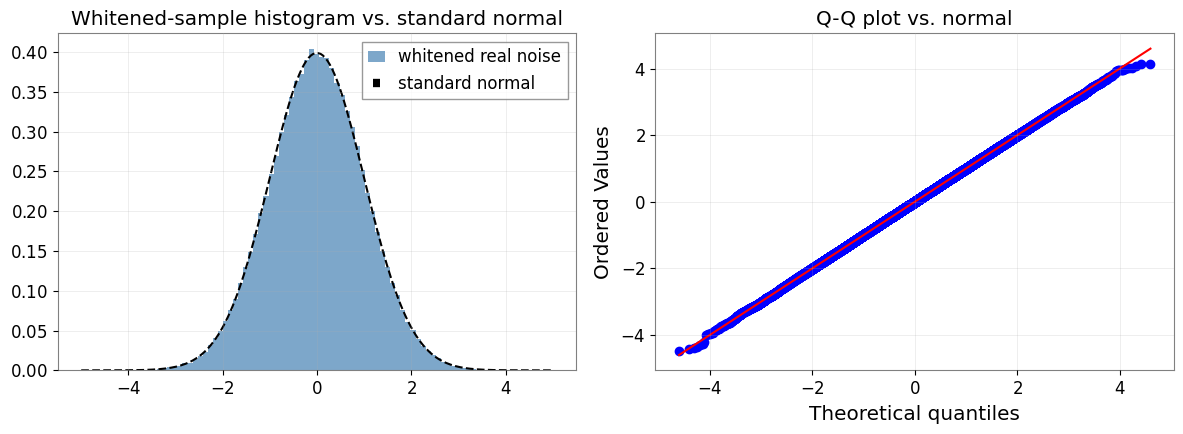

KS test vs. standard normal: statistic=0.0015, p=4.589e-01
Expect a non-trivial deviation from perfect Gaussianity (real detector noise, incl. occasional
glitches) -- this is informative, not a bug, and is exactly why later notebooks calibrate
detection thresholds empirically from real noise rather than assuming a closed-form null.


In [ ]:
# ---------------------------------------------------------------------------
# 6c. Approximate-Gaussianity check
# ---------------------------------------------------------------------------
from scipy import stats

sample = whitened_windows['calib_block'][:200].flatten()
assert np.all(np.isfinite(sample)), "Sample for Gaussianity check contains non-finite values!"
sample = sample / sample.std()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(sample, bins=80, density=True, alpha=0.7, color='steelblue', label='whitened real noise')
xs = np.linspace(-5, 5, 200)
axes[0].plot(xs, stats.norm.pdf(xs), color='k', ls='--', label='standard normal')
axes[0].set_title('Whitened-sample histogram vs. standard normal')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

stats.probplot(sample, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q plot vs. normal')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'plot_whitening_gaussianity_check.pdf'))
plt.show()

ks_stat, ks_p = stats.kstest(sample, 'norm')
print(f"KS test vs. standard normal: statistic={ks_stat:.4f}, p={ks_p:.3e}")
print("Expect a non-trivial deviation from perfect Gaussianity (real detector noise, incl. occasional")
print("glitches) -- this is informative, not a bug, and is exactly why later notebooks calibrate")
print("detection thresholds empirically from real noise rather than assuming a closed-form null.")


In [ ]:
# ---------------------------------------------------------------------------
# 6d. Explicit no-overlap assertion across blocks (belt-and-suspenders, re-derived from GPS numbers)
# ---------------------------------------------------------------------------
assert_non_overlapping(BLOCKS)

for name in ['calib_block', 'train_block', 'test_block']:
    n_win = whitened_windows[name].shape[0]
    # Use the ACTUAL per-window duration (N_SAMPLES_WINDOW / FS), not the nominal WINDOW_DUR --
    # int(FS * WINDOW_DUR) truncates, so each window is very slightly shorter than the nominal
    # 0.1 s, and multiplying by the nominal value instead of the true one accumulates a spurious
    # overshoot across thousands of windows. This was a bug in the check, not in the data.
    span_s = n_win * (N_SAMPLES_WINDOW / FS)
    assert span_s <= BLOCKS[name]['duration'] + 1e-6, f"{name}: windows exceed block duration!"

print("OK: window pools are consistent with non-overlapping GPS block boundaries.")


OK: all GPS blocks are non-overlapping.
OK: window pools are consistent with non-overlapping GPS block boundaries.


## 7. Example: raw vs. whitened window

A quick visual spot-check on a single calibration window, just to eyeball that whitening is doing
something sensible before moving on to Notebook 2 (signal injection).


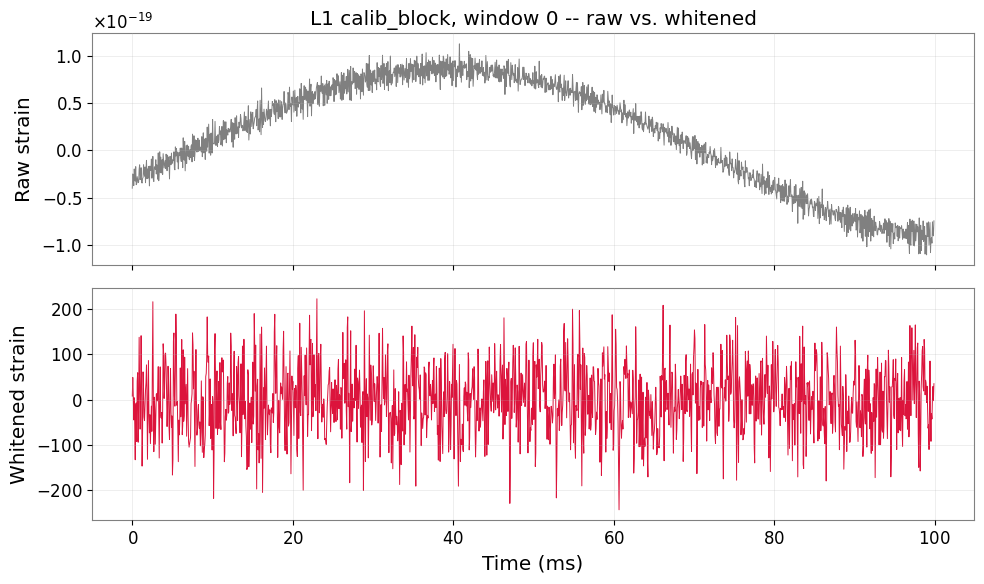

In [ ]:
# ---------------------------------------------------------------------------
# 7. Example plot
# ---------------------------------------------------------------------------
idx = 0
# Use the SAME windows as the saved pool (post edge-trim), and the matching raw stretch, so this plot
# is representative of what the pipeline actually produces.
raw_windows_calib = make_windows(raw_strain['calib_block'][edge_trim_samples: -edge_trim_samples])
raw_example = raw_windows_calib[idx]
whitened_example = whitened_windows['calib_block'][idx]
t_axis = np.arange(N_SAMPLES_WINDOW) / FS * 1000  # ms

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(t_axis, raw_example, color='gray', lw=0.7)
axes[0].set_ylabel('Raw strain')
axes[0].set_title(f'{DETECTOR} calib_block, window {idx} -- raw vs. whitened')
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_axis, whitened_example, color='crimson', lw=0.7)
axes[1].set_ylabel('Whitened strain')
axes[1].set_xlabel('Time (ms)')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'plot_raw_vs_whitened_example.pdf'))
plt.show()


## 8. Artifacts saved by this notebook

```
nb1_artifacts/
  gps_blocks.json                    # ACTUAL (post-search) GPS boundaries for all 4 blocks
  raw_<block>_L1.npy                 # cached, verified NaN-free raw strain per block (fs = 16384 Hz)
  raw_<block>_L1_meta.json           # actual vs. requested start, gap fraction found during search
  estimated_psd.npz                  # freqs, psd  -- the single PSD used for ALL whitening downstream
  whitened_calib_block.npy           # (n_windows, 1638) whitened, non-overlapping 100ms windows
  whitened_train_block.npy
  whitened_test_block.npy
  plot_*.pdf                         # sanity-check figures for the paper's reproducibility appendix
```

If you re-run this notebook from a clean `nb1_artifacts/` directory and get **different** GPS boundaries
than a previous run, that's expected and fine.
